In [1]:
import numpy as np
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df=pd.read_csv('C:/Users/shivs/OneDrive/Desktop/fyp/Darkpattern/Model/dark-patterns.csv')
#C:\Users\shivs\OneDrive\Desktop\fyp\Darkpattern\Model\
#C:\Users\shivs\OneDrive\Desktop\fyp\Darkpattern\Model\dark-patterns.csv

In [ ]:
df

,Pattern String,Comment,Pattern Category,Pattern Type,Where in website?,Deceptive?,Website Page
0,Collin P. from Grandview Missouri just bought ...,Periodic popup,Social Proof,Activity Notification,Product Page,No,https://alaindupetit.com/collections/all-suits...
1,"Faith in Glendale, United States purchased a C...",Periodic popup,Social Proof,Activity Notification,Product Page,No,https://bonescoffee.com/products/strawberry-ch...
2,Sharmeen Atif From Karachi just bought Stylish...,Periodic popup,Social Proof,Activity Notification,Product Page,No,https://brandsego.com/collections/under-rs-99/...
3,9 people are viewing this.,Product detail,Social Proof,Activity Notification,Product Page,No,https://brightechshop.com/products/ambience-so...
4,5338 people viewed this in the last hour,Periodic popup,Social Proof,Activity Notification,Product Page,No,https://bumpboxes.com/
...,...,...,...,...,...,...,...
1813,$132.90 $99.00,Website adds free items to show discount,Misdirection,Visual Interference,Cart Page,No,https://www.planetofthevapes.com/products/plan...
1814,This offer is only VALID if you add to cart now!,Popup asking you to buy more,Misdirection,Visual Interference,Product Page,No,https://www.rockymountainoils.com/single-essen...
1815,NaN,Deterministic draw. Always give you the prize ...,Misdirection,Visual Interference,Product Page,Yes,https://www.sammydress.com/
1816,NaN,Shows you prices in the popup based on your cu...,Misdirection,Visual Interference,Product Page,No,https://www.shoedazzle.com/products/FEELIN-A-L...


# Task
Apply clustering on the dataset using only the 'Pattern String' and 'Pattern Category' columns to identify patterns and categorize them.

## Select relevant columns

### Subtask:
Extract the 'Pattern String' and 'Pattern Category' columns from the dataset.


**Reasoning**:
Extract the specified columns into a new DataFrame.



In [ ]:
df_subset = df[['Pattern String', 'Pattern Category']]
display(df_subset.head())

,Pattern String,Pattern Category
0,Collin P. from Grandview Missouri just bought ...,Social Proof
1,"Faith in Glendale, United States purchased a C...",Social Proof
2,Sharmeen Atif From Karachi just bought Stylish...,Social Proof
3,9 people are viewing this.,Social Proof
4,5338 people viewed this in the last hour,Social Proof


## Preprocess text data

### Subtask:
Convert the 'Pattern String' column into numerical representations suitable for clustering. This will likely involve techniques like TF-IDF or word embeddings.


**Reasoning**:
Convert the 'Pattern String' column into numerical representations suitable for clustering using TF-IDF.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_subset['Pattern String'] = df_subset['Pattern String'].fillna('')

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_subset['Pattern String'])

/tmp/ipython-input-3875902361.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['Pattern String'] = df_subset['Pattern String'].fillna('')


## Apply clustering algorithm

### Subtask:
Choose and apply a clustering algorithm (e.g., K-Means, DBSCAN) to the numerical data derived from 'Pattern String'.


**Reasoning**:
Apply KMeans clustering to the TF-IDF matrix.



In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

df_subset['cluster_label'] = kmeans.labels_

/tmp/ipython-input-3917804883.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['cluster_label'] = kmeans.labels_


**Reasoning**:
Display the updated dataframe with the cluster labels to verify the result.



In [ ]:
display(df_subset.head())

,Pattern String,Pattern Category,cluster_label
0,Collin P. from Grandview Missouri just bought ...,Social Proof,6
1,"Faith in Glendale, United States purchased a C...",Social Proof,6
2,Sharmeen Atif From Karachi just bought Stylish...,Social Proof,6
3,9 people are viewing this.,Social Proof,0
4,5338 people viewed this in the last hour,Social Proof,0


## Analyze clustering results

### Subtask:
Evaluate the clustering results, potentially by comparing the clusters to the 'Pattern Category' column to see how well the clusters align with the existing categories.


**Reasoning**:
Calculate and print the count and proportion of each 'Pattern Category' within each 'cluster_label' to evaluate clustering results.



In [ ]:
category_cluster_counts = df_subset.groupby(['cluster_label', 'Pattern Category']).size().unstack(fill_value=0)
display("Category counts within each cluster:")
display(category_cluster_counts)

category_cluster_proportions = category_cluster_counts.apply(lambda x: x / x.sum(), axis=1)
display("Category proportions within each cluster:")
display(category_cluster_proportions)

'Category counts within each cluster:'

Pattern Category,Forced Action,Misdirection,Obstruction,Scarcity,Sneaking,Social Proof,Urgency
cluster_label,,,,,,,
0,0,2,0,12,0,107,0
1,0,0,0,222,0,0,0
2,0,52,0,0,0,0,0
3,0,30,0,0,0,0,0
4,0,2,0,2,0,0,74
5,0,0,0,35,0,0,0
6,6,115,31,168,26,218,407
7,0,0,0,24,0,0,0
8,0,0,0,216,0,0,0


'Category proportions within each cluster:'

Pattern Category,Forced Action,Misdirection,Obstruction,Scarcity,Sneaking,Social Proof,Urgency
cluster_label,,,,,,,
0,0.000000,0.016529,0.000000,0.099174,0.000000,0.884298,0.000000
1,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.025641,0.000000,0.025641,0.000000,0.000000,0.948718
5,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
6,0.006179,0.118435,0.031926,0.173018,0.026777,0.224511,0.419156
7,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000


## Visualize results

### Subtask:
(Optional) Visualize the clusters to gain a better understanding of the groupings.


**Reasoning**:
Visualize the clusters using PCA for dimensionality reduction and a scatter plot.



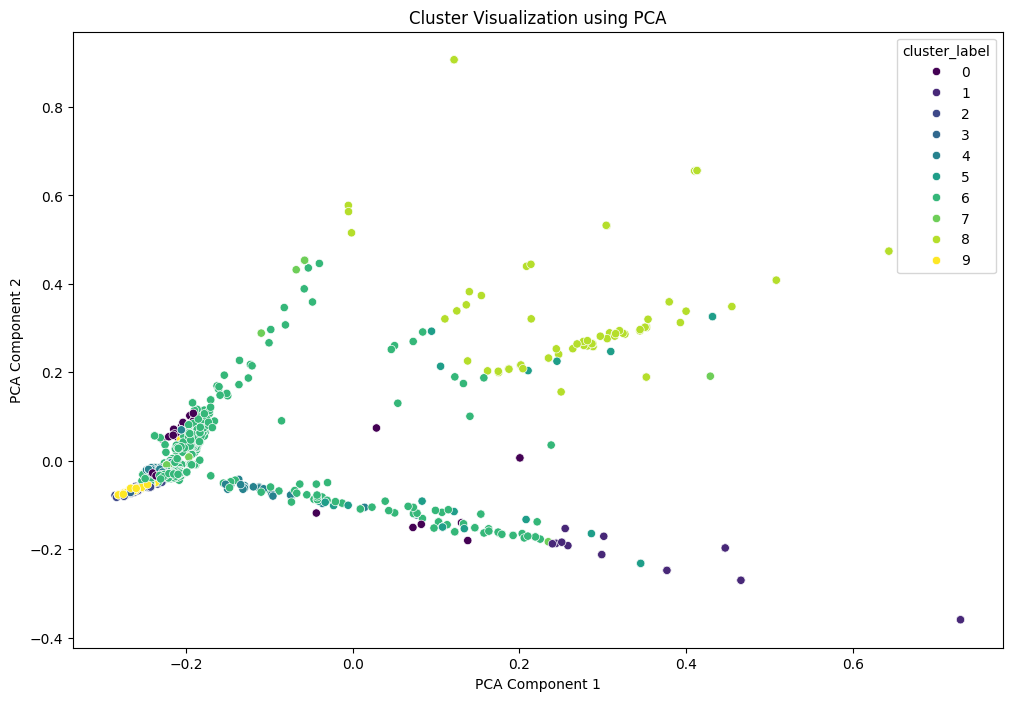

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
tfidf_pca = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(12, 8))
sns.scatterplot(x=tfidf_pca[:, 0], y=tfidf_pca[:, 1], hue=df_subset['cluster_label'], palette='viridis', legend='full')
plt.title('Cluster Visualization using PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

## Summary:

### Data Analysis Key Findings

*   Clustering was applied to the 'Pattern String' data using TF-IDF for text representation and K-Means with 10 clusters.
*   Several clusters show a strong dominance of a single 'Pattern Category', indicating a good alignment between the clustering and the existing categories for those specific groups (e.g., Cluster 1, 2, 3, 5, 7, 8, 9).
*   Other clusters contain a mix of 'Pattern Categories', suggesting that the patterns within these clusters are less distinctly separable based on the 'Pattern String' alone according to the predefined categories (e.g., Cluster 0, 4, 6).

### Insights or Next Steps

*   Investigate the clusters with mixed categories to understand why they are not clearly separated and if there are sub-patterns within these clusters.
*   Consider exploring different clustering algorithms or text representation methods to potentially improve the alignment of clusters with the 'Pattern Category'.


/tmp/ipython-input-2217553795.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Pattern Category', order=df['Pattern Category'].value_counts().index, palette='viridis')


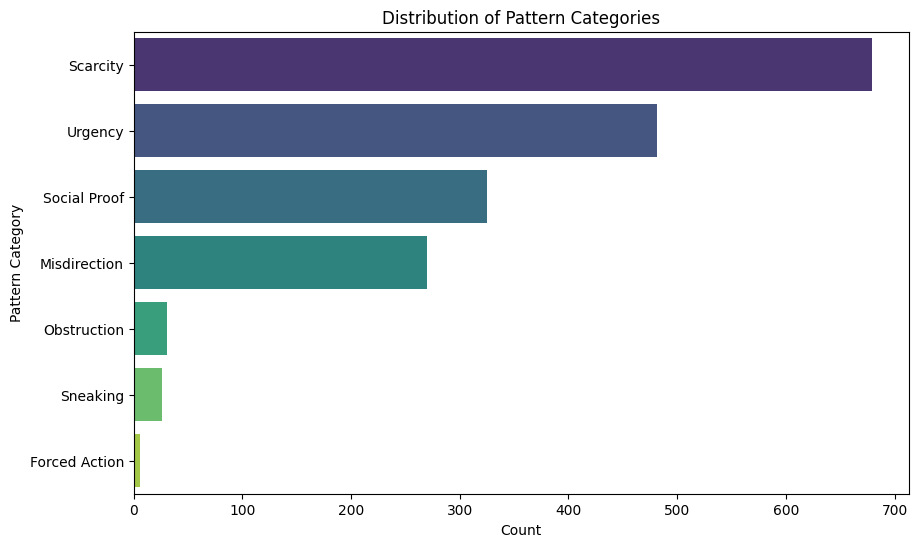

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Pattern Category', order=df['Pattern Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Pattern Categories')
plt.xlabel('Count')
plt.ylabel('Pattern Category')
plt.show()

In [5]:
import pickle as pk

# Example data to save
my_data = {'key': 'value', 'number': 123}

# Correct usage of with open and pk.dump
# 'filename.pkl' should be replaced with your desired file path
# 'wb' stands for write binary mode, which is necessary for pickle
with open('my_data.pkl', 'wb') as file:
    pk.dump(my_data, file)